In [1]:
import py4DSTEM
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

# Load Data

In [2]:
PeaksArray = np.load('PeaksArray_SmallRange.npy')

# Columns represent Qx, Qy, I, Rx, Ry, Qr, Qphi
Qx = PeaksArray[:, 0]
Qy = PeaksArray[:, 1]
Rx = PeaksArray[:, 3]
Ry = PeaksArray[:, 4]

In [3]:
# Set same text size
plt.rcParams.update({'font.size': 14})

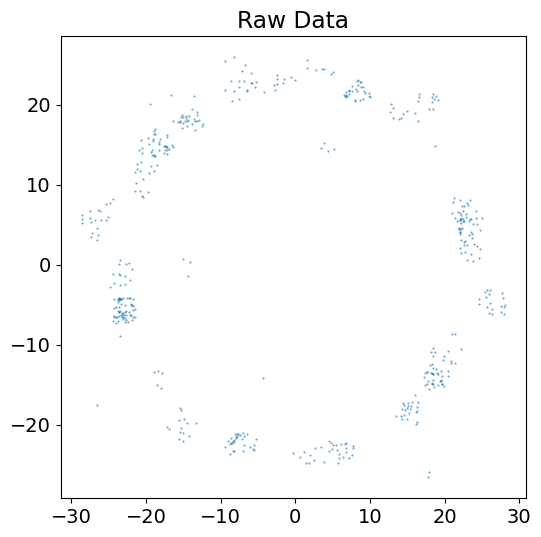

In [4]:
# Plot the data
plt.figure(figsize=[6,6])
plt.title('Raw Data')
plt.scatter(Qx, Qy, s=0.25, alpha=0.7)
plt.show()

## Applying DBSCAN Clustering

## Level 1 Clustering

In [6]:
# DBScan Parameters
s = 0.4 
eps = 2
db1 = DBSCAN(eps=eps, min_samples=4).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, s, s])) 

In [7]:
# Colour Scheme
colours = []
r = db1.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

### Plots

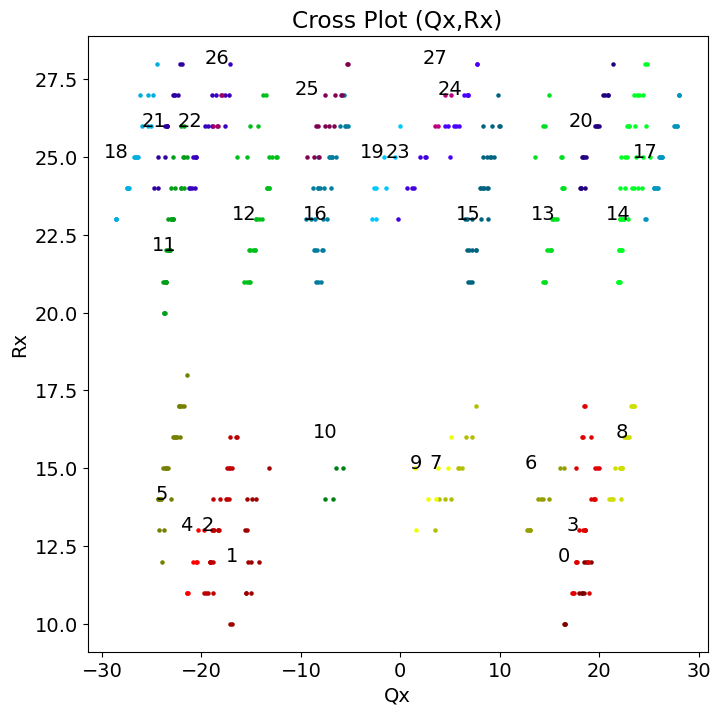

In [8]:
# Cross Plot (Qx,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Rx)')

r = db1.labels_.max()+1

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Rx')
plt.show()

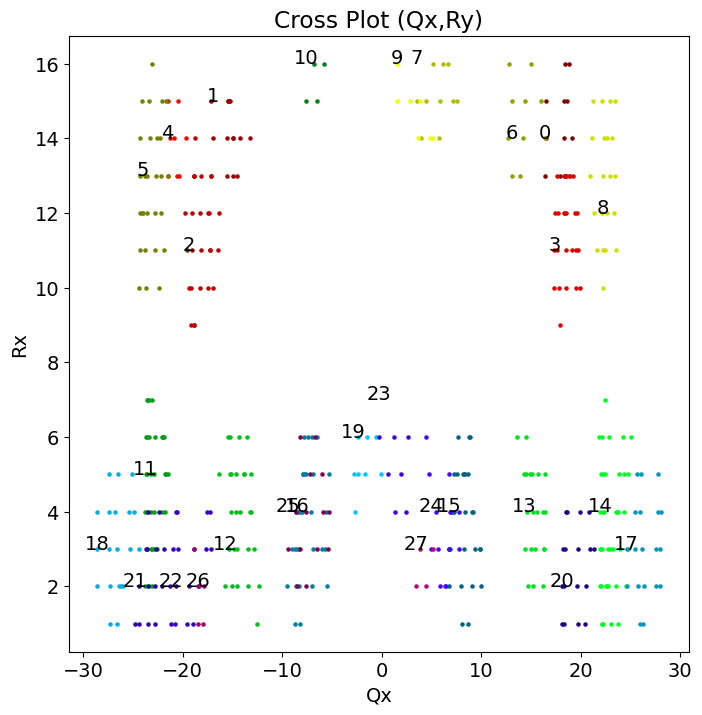

In [9]:
# Cross Plot (Qx,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Rx')
plt.show()

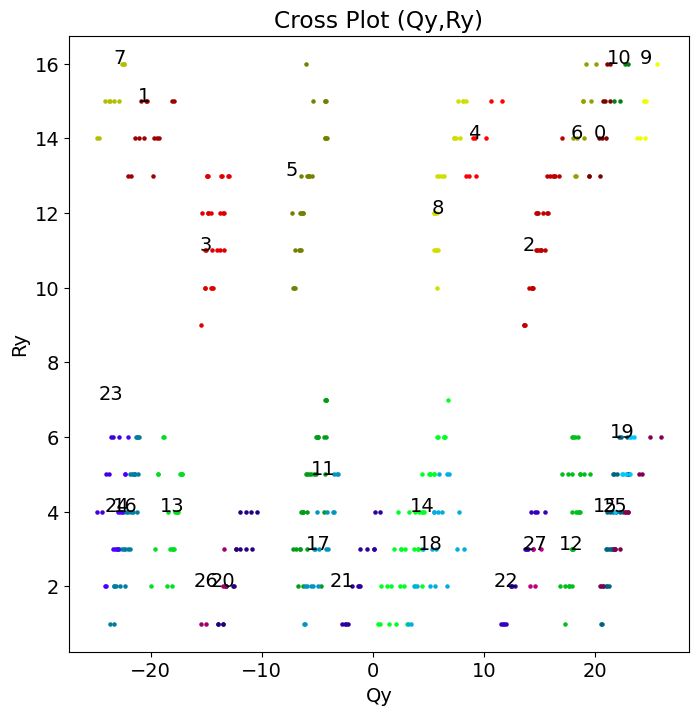

In [10]:
# Cross Plot (Qy,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Ry')
plt.show()

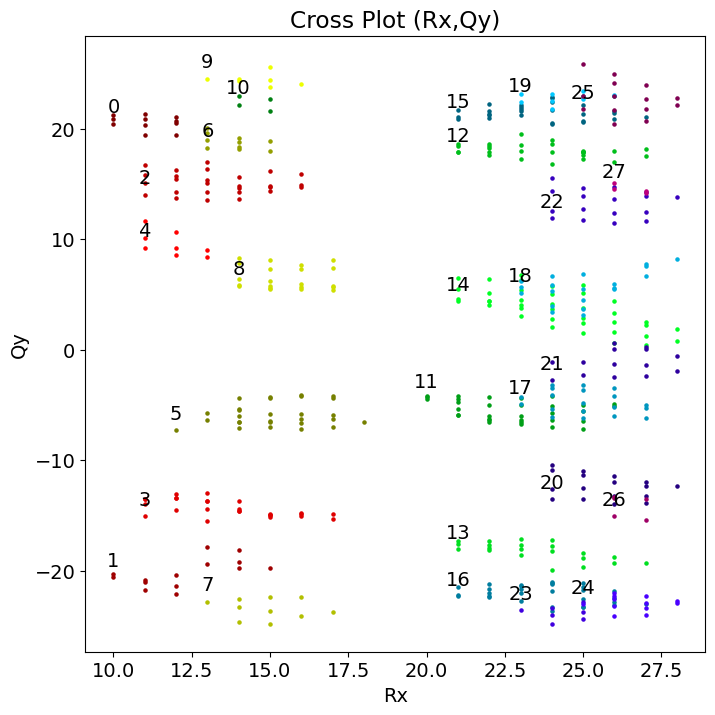

In [11]:
# Cross Plot (Rx,Qy)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Rx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 3], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 3], 
            Cluster[n, 1]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Rx')
plt.ylabel('Qy')
plt.show()

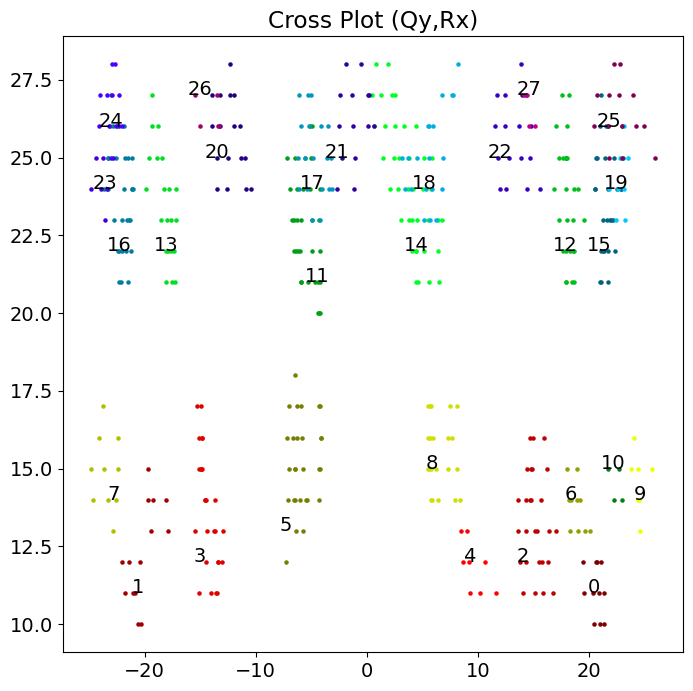

In [12]:
# Cross Plot (Qy,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 3]+1, 
            int(i),
            horizontalalignment='center'
        )

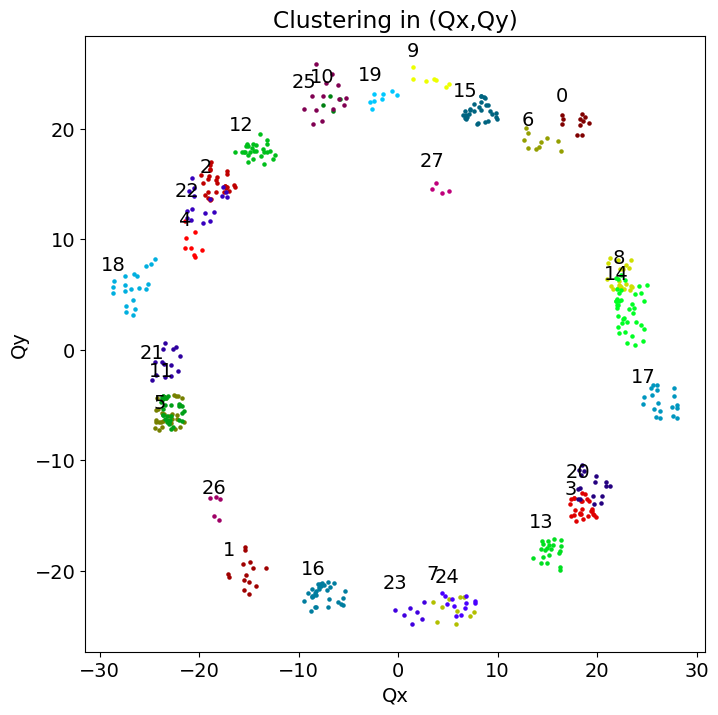

In [13]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Qy')
plt.show()

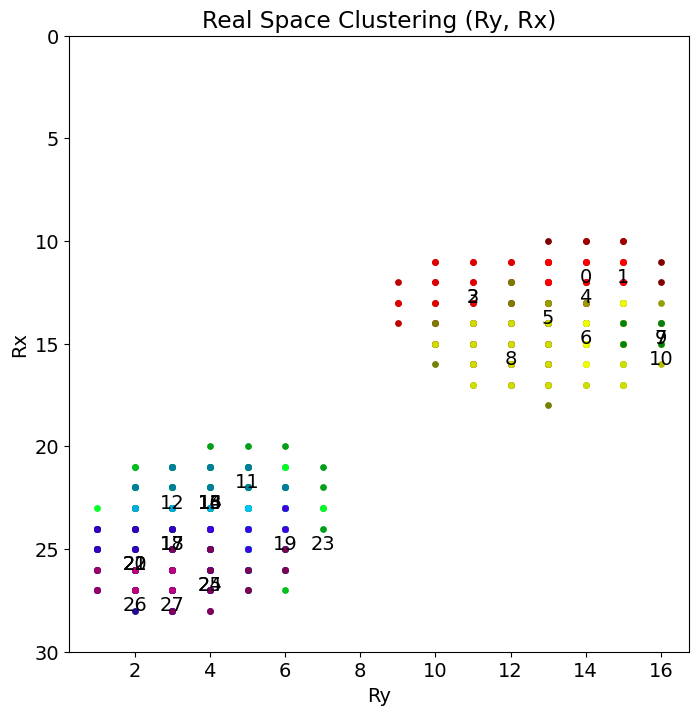

In [14]:
# Real space
plt.figure(figsize=[8,8])
plt.title('Real Space Clustering (Ry, Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 4], Cluster[:, 3], color = colours[i], label = i, s=15, alpha=1)
    
    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 4]+1, 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Ry')
plt.ylabel('Rx')
plt.ylim(30,0)
plt.show()

## Centre of Mass (COM)

In [15]:
# find COM for each cluster
def COM_X(m,x):
    '''
    Calculates COM for x-coordinate.

    Data types:
    m: int or numpy array
    x: numpy array
    '''
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    '''
    Calculates COM for y-coordinate.

    Data types:
    m: int or numpy array
    y: numpy array
    '''
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, label, Weight=True):
    '''
    Calculates COM for every cluster in a clustering graph.
    
    Data types:
    Data: numpy array
    Range: numpy array
    label: numpy array
    Weight: bool
        if True, applies pixel weighting to the centre of masses

    '''
    COM_Values = []

    # loop over all clusters
    for p in Range:
        Cluster = Data[np.where(label == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [16]:
COM_Values = Cluster_COM(PeaksArray, np.arange(0, max(db1.labels_)+1,1), db1.labels_, Weight = True)

In [17]:
COM_Values = np.array(COM_Values)

## Level 2 Clustering (Clustering on COM)

In [18]:
# Second level clustering on COM
db2 = DBSCAN(eps=1, min_samples=2).fit(COM_Values)

In [19]:
# Colour Scheme
colours = [] 
r = db2.labels_.max()+1 
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

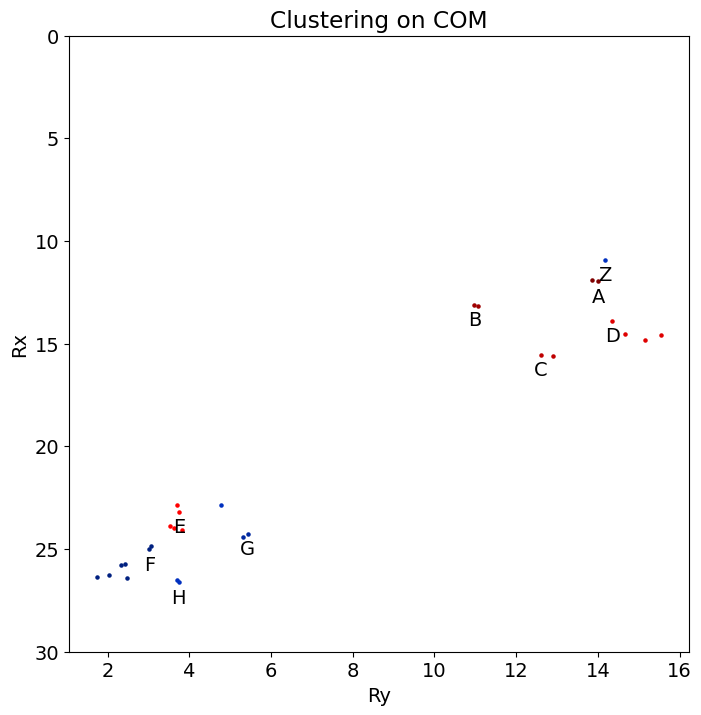

In [41]:
# Plot
plt.figure(figsize=[8,8])
plt.title('Clustering on COM')

Text = string.ascii_uppercase
db2labels = np.unique(db2.labels_) 

for i in db2labels:
    Cluster = COM_Values[np.where(db2.labels_ == i)]
    scatter = plt.scatter(Cluster[:,1], Cluster[:,0], color = colours[i], label = i, s=5, alpha=1)

    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+1, 
            str(Text[i]),
            horizontalalignment='center'
        )
plt.ylim(30,0)
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.show()

# this is the crystal / clustering analysis
# nearby clusters could suggest occuring from the same crystal

## Digital Dark Field Images 

In [42]:
def VirtualImage(Data, Label, Index, savefig = True, figax = None):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster.

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    figax: tuple, None
        (fig, ax)
    
    Return: 
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Data[:,3].max().astype('int')+1, Data[:,4].max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

    # Plot
    if figax != None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(figsize=[7,7])

    ax.imshow(image)
      
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()
         
    if savefig:
        fig.savefig('DigitalDarkFieldImage')

## Transfer level 1 and level 2 cluster labels into the data array 

In [47]:
# Identify the unique labels in level 2
L2numlabs = np.append(db2labels[db2labels != -1], -1) # set last number to be -1

# Insert alphabetical letters
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

# Create dict
labs1 = dict(list(zip(L2numlabs, L2letterlabs))) # numbers to letters
labs2 = dict(list(zip(L2letterlabs, L2numlabs))) # letters to numbers

# Ensure noise is Z = -1
labs1[-1] = 'Z'
labs2['Z'] = -1

# Add level 1 labels to data array
Dataset = np.column_stack((PeaksArray, db1.labels_))

# Indexing to ensure correct length of lvl2 labels, also maps lvl1 clusters to lvl2 clusters
indexing = db2.labels_[db1.labels_]

# Source - https://stackoverflow.com/a/57058920
# Posted by yatu
# Retrieved 2026-03-15, License - CC BY-SA 4.0
lvl2 = np.vectorize(labs1.get)(indexing.astype(int))

# Add level 2 labels to data array
FullDataset = np.column_stack((Dataset, lvl2))

# New Data Array Columns
Qx = FullDataset[:,0]
Qy = FullDataset[:,1]
I = FullDataset[:,2]
Rx = FullDataset[:,3]
Ry = FullDataset[:,4] 
Qr = FullDataset[:,5]
Qphi = FullDataset[:,6]
Clusters1 = FullDataset[:,7]
Clusters2 = FullDataset[:,8] 

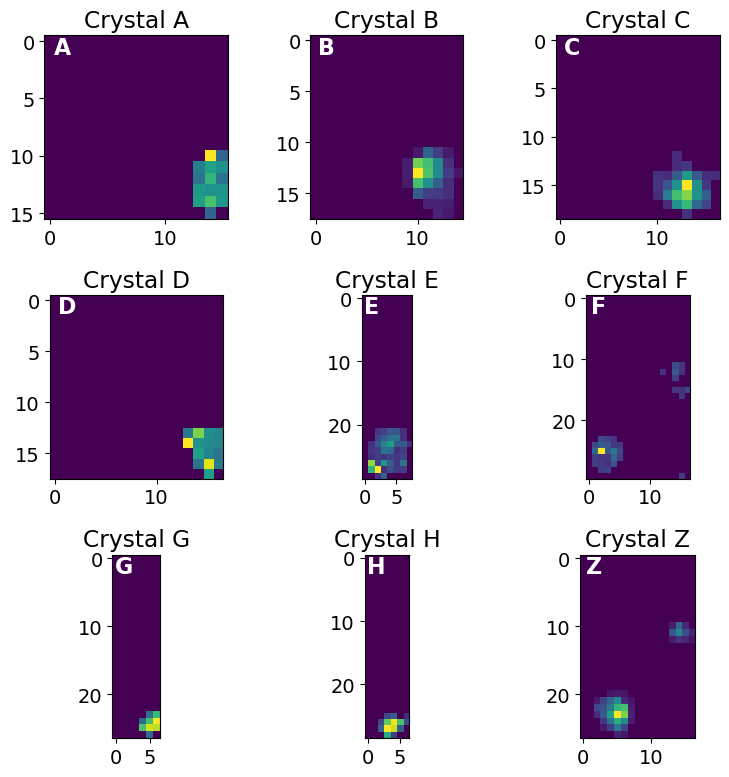

In [72]:
# Subplots
fig, axes = plt.subplots(nrows=(3), ncols=(3), figsize=[8,8])
axes = axes.flatten()
    
for i, j in enumerate(np.unique(lvl2)):
    
    CL = FullDataset[:, 8] == j
    Vectors = FullDataset[CL]
    CrystalData = Vectors[:,0:8].astype(float)

    Rxc = CrystalData[:,3]
    Ryc = CrystalData[:,4]

    Rxmax = int(Rxc.max()) + 1
    Rymax = int(Ryc.max()) + 1

    image = np.zeros((Rxmax, Rymax))
    image[Rxc.astype(int), Ryc.astype(int)] = CrystalData[:,2]
    
    axes[i].imshow(image)
    axes[i].set_title('Crystal {0}'.format(j))
    axes[i].text(
    0.05, 0.9, j,
    transform=axes[i].transAxes,
    fontsize=16,
    color='white',
    weight='bold'
)
    #axes[i].set_xlabel('Ry')
    #axes[i].set_ylabel('Rx')
    fig.tight_layout()


In [73]:
def IndividualCrystal(Letter): 

    # Example Select Crystal Label (CL)
    CL = FullDataset[:, 8] == Letter

    # All diffraction vectors associated with Crystal A 
    Vectors = FullDataset[CL]

    # Change values into floats
    # this is the dataset with all the clusters contained in 'A'
    CrystalData = Vectors[:,0:8].astype(float)

    # Select Rx, Ry components of A
    Rxc = CrystalData[:,3]
    Ryc = CrystalData[:,4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = CrystalData[:,3].max().astype('int')+1, CrystalData[:,4].max().astype('int')+1

    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = CrystalData[:,2]

    # Plot
    fig, ax = plt.subplots(figsize=[6,6])

    ax.imshow(image)
    ax.set_title('Crystal {0}'.format(Letter)) # change
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()

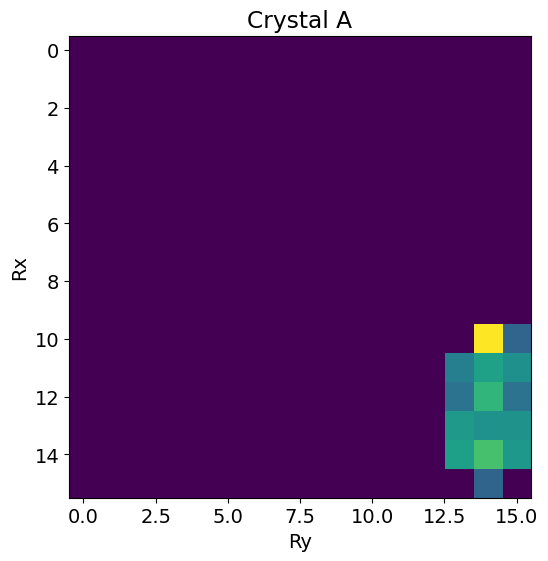

In [74]:
IndividualCrystal('A')

In [216]:
# Clustering on (Qx, Qy, Rx, Ry)
# DBScan Parameters
db3 = DBSCAN(eps=0.4, min_samples=1).fit(CA_Data[:,[0, 1, 3, 4]]) 

# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

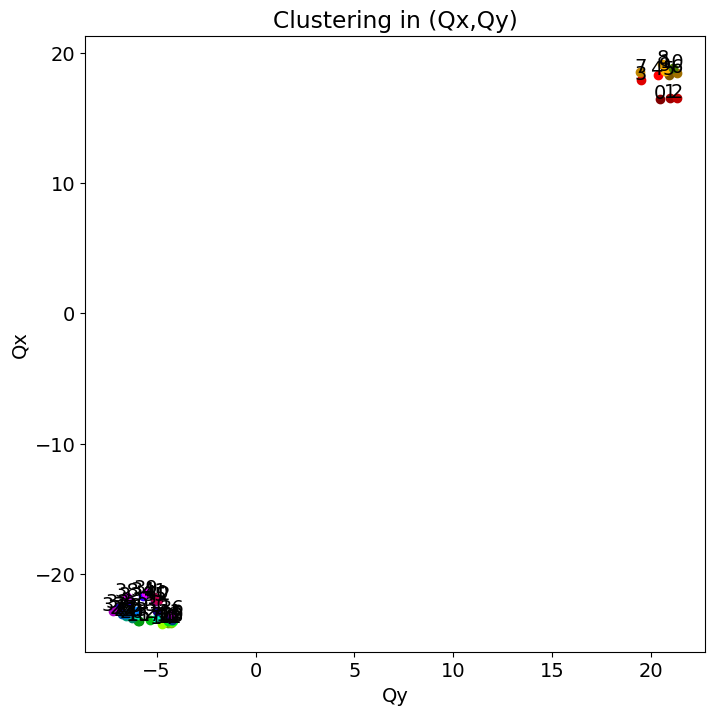

In [156]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CA_Data[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 0], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+0.03, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Qx')
plt.show()

In [146]:
Cluster = CA_Data[np.where(db3.labels_ == 8)]

In [147]:
Rxc = Cluster[:, 3]
Ryc = Cluster[:, 4]

In [224]:
# Finding max dimensions of Rx, Ry
Rxmax, Rymax = CA_FullDataset[:,3].max().astype('int')+1, CA_FullDataset[:,4].max().astype('int')+1

UFuncTypeError: ufunc 'maximum' did not contain a loop with signature matching types (dtype('<U32'), dtype('<U32')) -> None

In [ ]:
# Create image 
image = np.zeros(shape=(Rxmax,Rymax))
image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

In [ ]:

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Data[:,3].max().astype('int')+1, Data[:,4].max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

    # Plot
    if figax != None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(figsize=[7,7])

    ax.imshow(image)
      
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()
         
    if savefig:
        fig.savefig('DigitalDarkFieldImage')

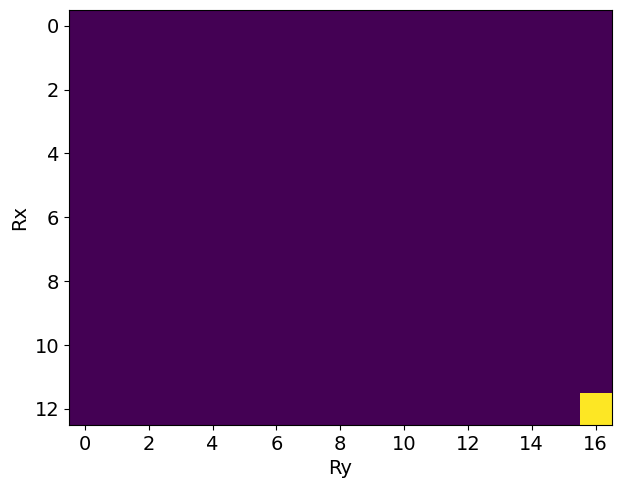

In [139]:
VirtualImage(CA_Data, db3.labels_, 9, savefig = False)

In [140]:
#VirtualImage(CA_Data, db3.labels_, 9, 3, 4, CA_Data[:,3], CA_Data[:,4])

In [141]:
#VirtualImage(CA_Data, db3.labels_, 8, 3, 4, CA_Data[:,3], CA_Data[:,4])

In [142]:
#VirtualImage(CA_Data, db3.labels_, 3, 3, 4, CA_Data[:,3], CA_Data[:,4])

In [66]:
# Notes
# The clusters so far appear to be in the same spatial region
# This could suggest they belong to the same crystal

In [70]:
# Example Select Crystal N (CN)
CN = FullDataset[:, 8] == 'N'

# All diffraction vectors associated with Crystal A
CN_FullDataset = FullDataset[CN]

# Change values into floats
CN_Data = CN_FullDataset[:,0:8].astype(float)

# Extract Qx, Qy from crystal N
Nqx = CN_Data[:,0]
Nqy = CN_Data[:,1]

In [71]:
# DBScan Parameters
#s = 0.4 
#eps = 1
db3 = DBSCAN(eps=1.5, min_samples=1).fit(CN_Data[:,[0, 1, 3, 4]]) 

# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

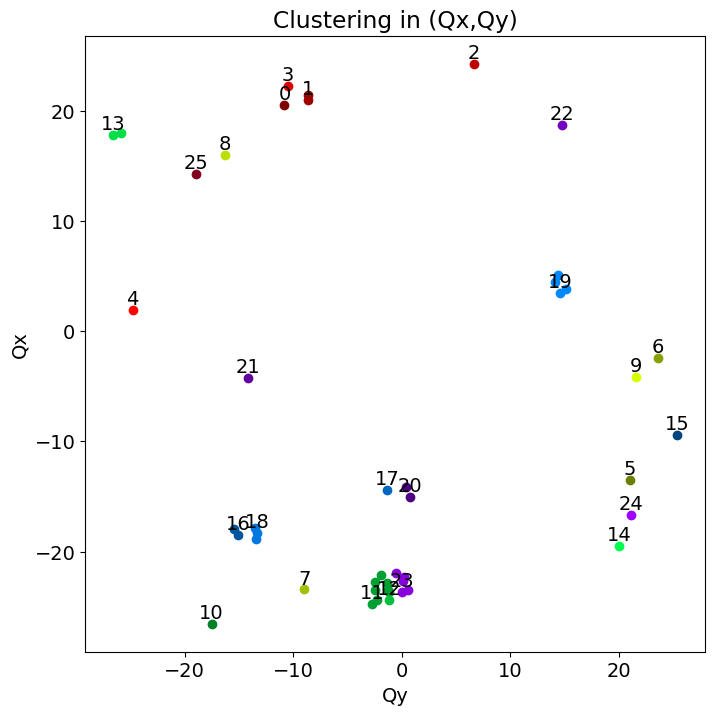

In [72]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CN_Data[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 0], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+0.5, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Qx')
plt.show()

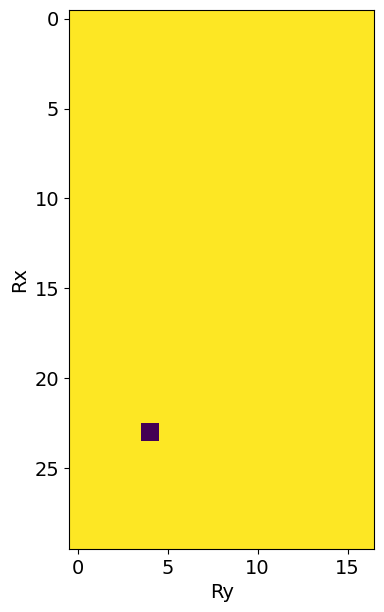

In [73]:
VirtualImage(CN_Data, db3.labels_, 10, 3, 4, CN_Data[:,3], CN_Data[:,4])

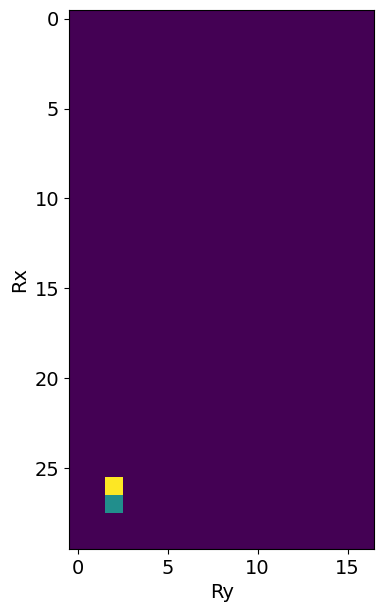

In [74]:
VirtualImage(CN_Data, db3.labels_, 20, 3, 4, CN_Data[:,3], CN_Data[:,4])

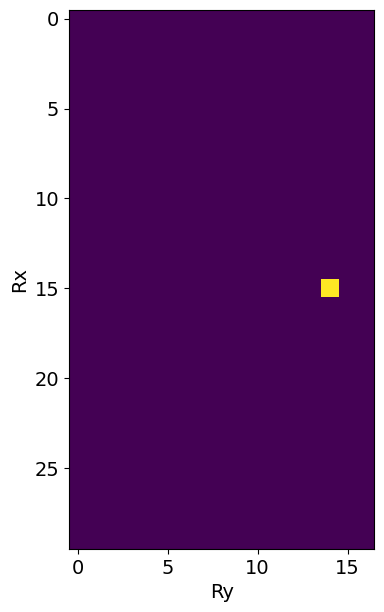

In [75]:
VirtualImage(CN_Data, db3.labels_, 6, 3, 4, CN_Data[:,3], CN_Data[:,4])

In [76]:
# Notes
# Notice that all the clusters dont appear to be in the same region
# Some of these clusters may correspond to noise from DBSCAN

**Compare two crystals**

In [77]:
# Cluster Data
CrystalA = CA_Data[np.where(db3.labels_ == 9)]
CrystalN = CN_Data[np.where(db3.labels_ == 10)]

In [78]:
# Select Rx, Ry
RxA = CrystalA[:, 3]
RyA = CrystalA[:, 4]

RxN = CrystalN[:, 3]
RyN = CrystalN[:, 4]

In [79]:
# Finding max dimensions of Rx, Ry
RxmaxA, RymaxA = RxA.max().astype('int')+1, RyA.max().astype('int')+1
RxmaxN, RymaxN = RxN.max().astype('int')+1, RyN.max().astype('int')+1

In [80]:
# Create image 
imageA = np.zeros(shape=(RxmaxA,RymaxA))
imageA[RxA.astype('int'), RyA.astype('int')]  = CrystalA[:,1]

imageN = np.zeros(shape=((RxmaxN),(RymaxN)))
imageN[RxN.astype('int'), RyN.astype('int')]  = CrystalN[:,1]

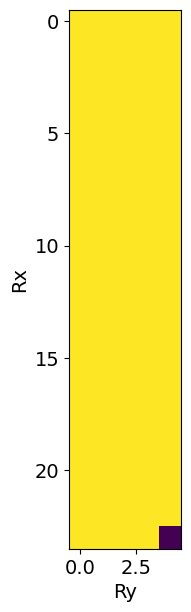

In [81]:
# Plot
fig, ax = plt.subplots(figsize=[7,7])

ax.imshow(imageA)
ax.imshow(imageN)
      
ax.set_xlabel('Ry')
ax.set_ylabel('Rx')

plt.show()
         
#if savefig:
    #fig.savefig('DigitalDarkFieldImage')